<h1>Install Library<h1>

In [ ]:
%pip install librosa torch torchvision matplotlib scikit-learn numpy pandas tqdm soundfile

  Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl (12.8 MB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.3/1.0 MB ? eta -:--:--
   ------------------------------ --------- 0.8/1.0 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 1.8 MB/s  0:00:00

   -- -------------------------------------  1/14 [pycparser]
  Attempting uninstall: numpy
   -- -------------------------------------  1/14 [pycparser]
    Found existing installation: numpy 2.4.0
   -- -------------------------------------  1/14 [pycparser]
   ----- ----------------------------------  2/14 [numpy]
    Uninstalling numpy-2.4.0:
   ----- ----------------------------------  2/14 [numpy]
      Successfully uninstalled numpy-2.4.0
   ----- ----------------------------------  2/14 [numpy]
   ----- ----------------------------------  2/14 [numpy]
   ----- ------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torchaudio (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torchaudio


<h1>See One Audio</h1>

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [2]:
filepath = "Data\\genres_original\\classical\\classical.00000.wav"
signal, sr = librosa.load(filepath,sr=22050)

c:\Users\Renish\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
len(signal)

661794

<h2>Plot Wave Form</h2>

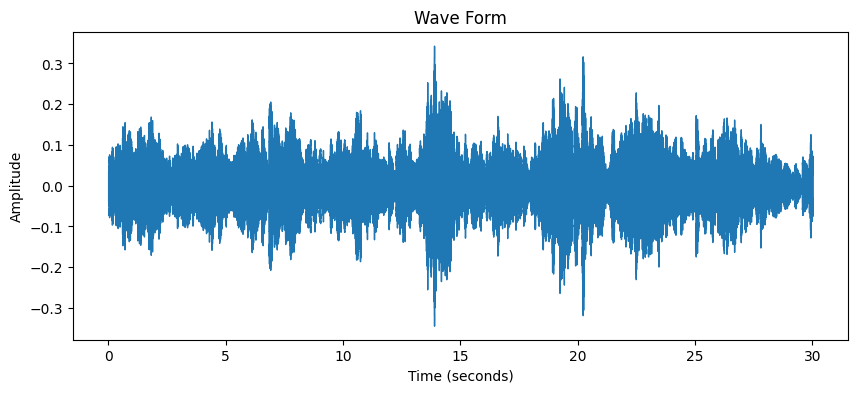

In [4]:
plt.figure(figsize=(10,4))
librosa.display.waveshow(signal,sr=sr)
plt.title("Wave Form")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [5]:
sr

22050

In [6]:
print(f"length of audio: {len(signal)/sr}")

length of audio: 30.013333333333332


<h1>Mel Spectogram</h1>

In [7]:
mel_spec = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128,
    n_fft=2048,
    hop_length=512
)

In [8]:
mel_spec.shape

# 128 = Mel frequency bands

# 1293 = time frames

(128, 1293)

<h1>Convert to Log Scale</h1>

In [9]:
mel_spec_db = librosa.power_to_db(mel_spec,ref=np.max)

In [10]:
mel_spec.shape

(128, 1293)

<h2>Plot Mel Spectogram</h2>

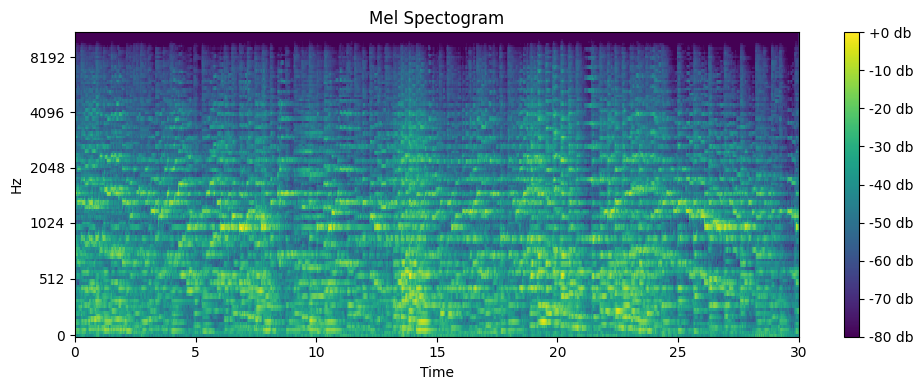

In [11]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="mel",
    cmap="viridis"
)

plt.colorbar(format='%+2.0f db')
plt.title("Mel Spectogram")
plt.tight_layout()
plt.show()

In [12]:
mean = mel_spec.mean()
std = mel_spec.std()

mel_spec = (mel_spec - mean) / std